<a href="https://colab.research.google.com/github/Shibu09-tech/AI-ML-Projects-and-Notes/blob/main/Lab2_Car_Price_Prediction/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Car Price Prediction using Machine Learning**

The aim of this project is to build a Machine Learning model that can predict the selling price of a car based on different features such as present price, kilometers driven, fuel type, transmission type, ownership, and car age.

In [12]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [13]:
# loading the dataset
df=pd.read_csv('/content/car_price.csv')

In [14]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### **Understanding the dataset**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [16]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [17]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [18]:
# Removing the unnecessary columns
df.drop('car_ID',axis=1,inplace=True)

In [19]:
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [20]:
df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### **Understanding Categorical and Numerical Data**

Encode Categorical **Features**

In [21]:
encoder = LabelEncoder()

categorical_features = [
    'CarName',
    'fueltype',
    'aspiration',
    'doornumber',
    'carbody',
    'drivewheel',
    'enginelocation',
    'enginetype',
    'cylindernumber',
    'fuelsystem'
]

for col in categorical_features:
    df[col] = encoder.fit_transform(df[col])

In [22]:
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,2,1,0,1,0,2,0,88.6,168.8,...,130,5,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,3,1,0,1,0,2,0,88.6,168.8,...,130,5,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,1,1,0,1,2,2,0,94.5,171.2,...,152,5,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,4,1,0,0,3,1,0,99.8,176.6,...,109,5,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,5,1,0,0,3,0,0,99.4,176.6,...,136,5,3.19,3.40,8.0,115,5500,18,22,17450.0


In [23]:
df.describe()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,77.209756,0.902439,0.180488,0.439024,2.614634,1.326829,0.014634,98.756585,174.049268,...,126.907317,3.253659,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,41.014583,0.297446,0.385535,0.497483,0.859081,0.556171,0.120377,6.021776,12.337289,...,41.642693,2.013204,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,86.600000,141.100000,...,61.000000,0.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,44.000000,1.000000,0.000000,0.000000,2.000000,1.000000,0.000000,94.500000,166.300000,...,97.000000,1.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,80.000000,1.000000,0.000000,0.000000,3.000000,1.000000,0.000000,97.000000,173.200000,...,120.000000,5.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,115.000000,1.000000,0.000000,1.000000,3.000000,2.000000,0.000000,102.400000,183.100000,...,141.000000,5.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,146.000000,1.000000,1.000000,1.000000,4.000000,2.000000,1.000000,120.900000,208.100000,...,326.000000,7.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## **Exploratory Data Analysis (EDA)**



**Correlation Heatmap**


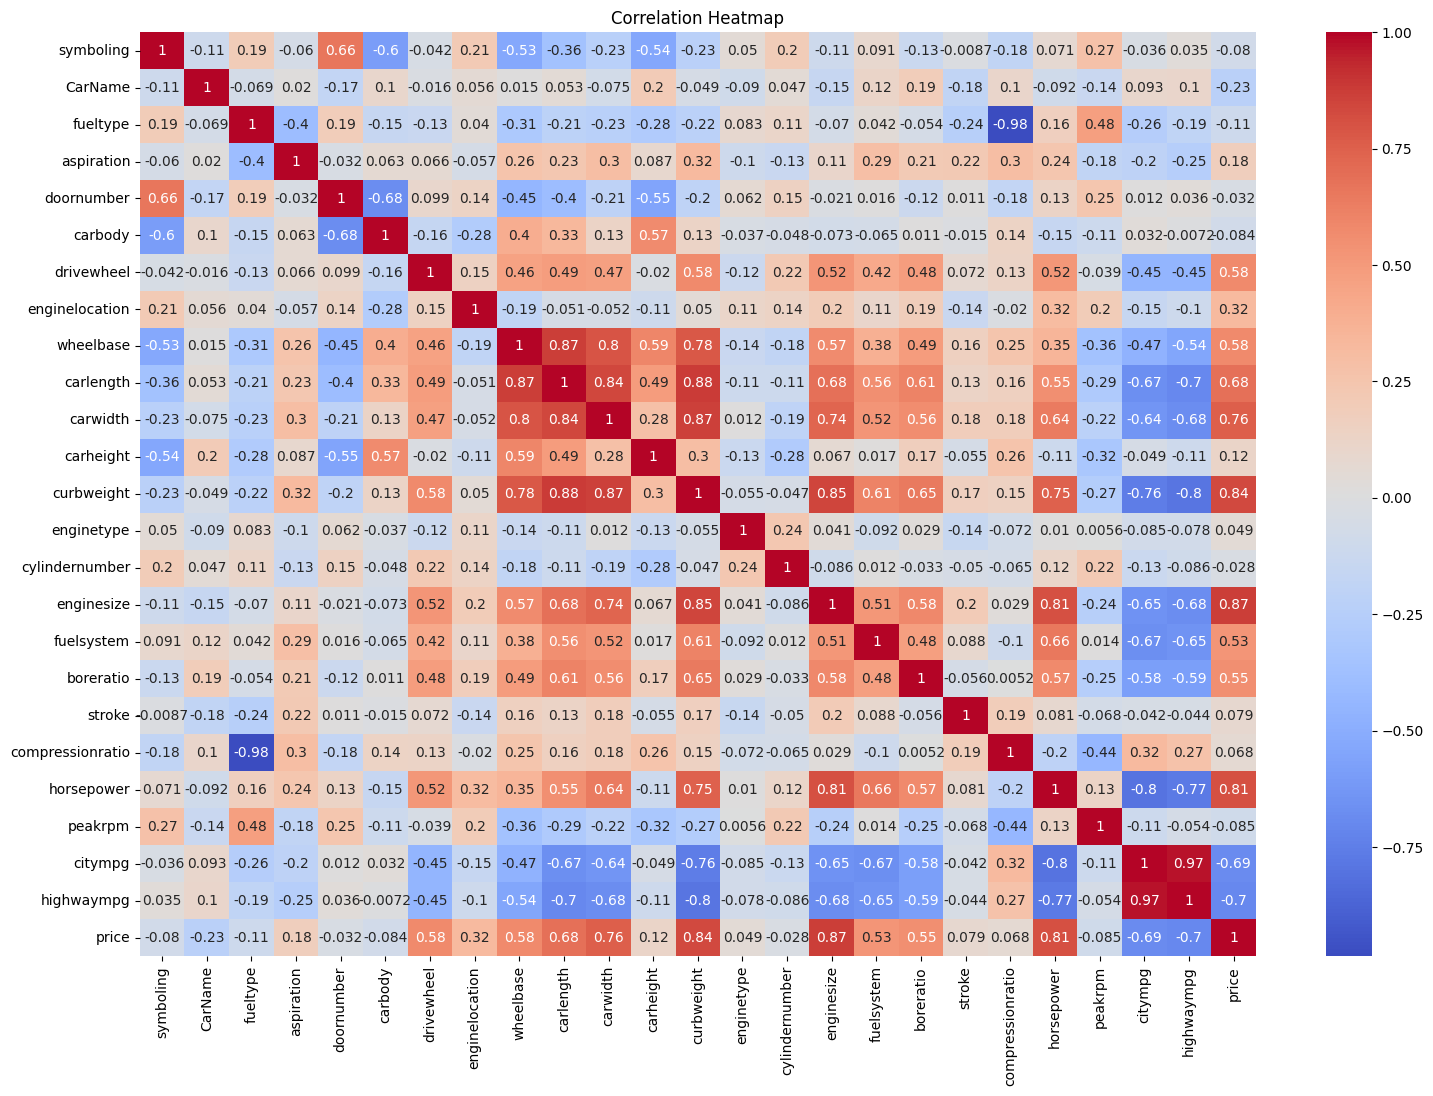

In [27]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(),annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**We observe the important relationships as :**

| Feature    | Relation with Price |
| ---------- | ------------------- |
| enginesize | Strong positive     |
| horsepower | Positive            |
| curbweight | Positive            |
| citympg    | Negative            |
| highwaympg | Negative            |


### **Visualize Important Features**

**Engine Size vs Price**

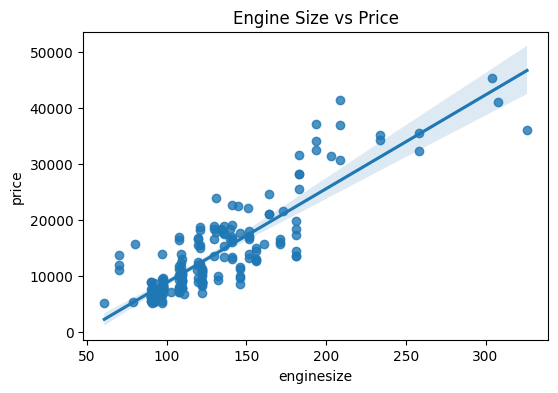

In [34]:
from seaborn.distributions import kdeplot
plt.figure(figsize=(6,4))

sns.regplot(
    x='enginesize',
    y='price',
    data=df,

)

plt.title('Engine Size vs Price')

plt.show()

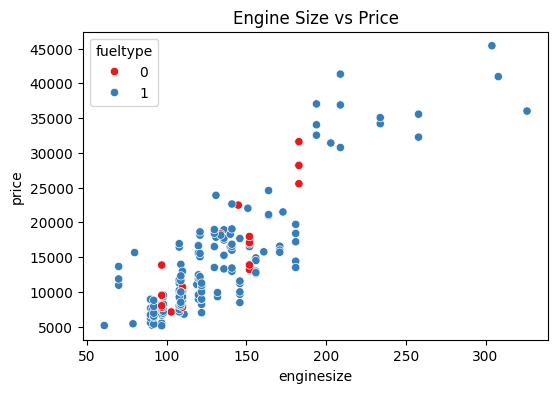

In [36]:
from seaborn.distributions import kdeplot
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='enginesize',
    y='price',
    data=df,
    hue='fueltype',
    palette='Set1'
)

plt.title('Engine Size vs Price')

plt.show()

### **Horsepower vs Price**

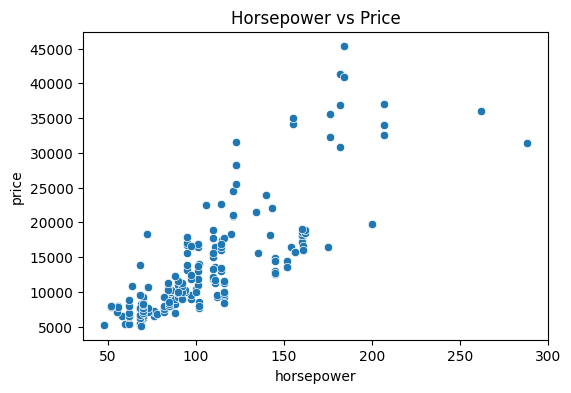

In [37]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='horsepower',
    y='price',
    data=df,

)

plt.title('Horsepower vs Price')

plt.show()

### **City MPG VS Price**

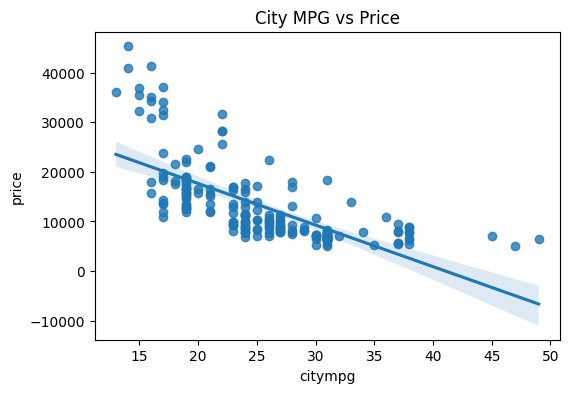

In [41]:
plt.figure(figsize=(6,4))

sns.regplot(
    x='citympg',
    y='price',
    data=df,

)

plt.title('City MPG vs Price')

plt.show()

### **Checking Outliers for price**

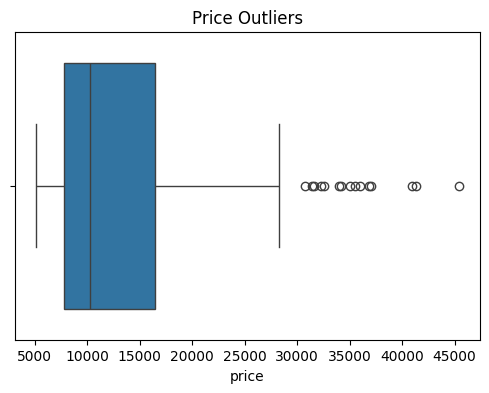

In [42]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['price'])

plt.title('Price Outliers')

plt.show()

### **Removing the Outliers**

**IQR Method**

In [48]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_new = df[
    (df['price'] >= lower_limit) &
    (df['price'] <= upper_limit)
]

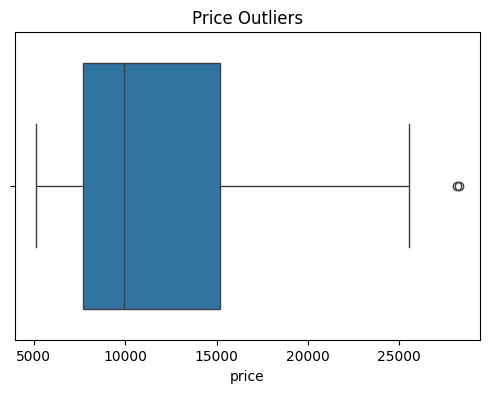

In [49]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df_new['price'])

plt.title('Price Outliers')

plt.show()

## **Feature Scaling**

In [50]:
X = df_new.drop('price', axis=1)

y = df_new['price']

In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [52]:
# Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## **Model 1 – Linear Regression**

In [53]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [54]:
lr_pred = lr_model.predict(X_test)

In [55]:
print('Linear Regression Results')

print('MAE:',
      mean_absolute_error(y_test, lr_pred))

print('RMSE:',
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print('R2 Score:',
      r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 1425.8552222061703
RMSE: 1797.8990472704609
R2 Score: 0.8077019455117778


## **Model 2 – Decision Tree**

In [56]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [57]:
dt_pred = dt_model.predict(X_test)

In [58]:
print('Decision Tree Results')

print('MAE:',
      mean_absolute_error(y_test, dt_pred))

print('RMSE:',
      np.sqrt(mean_squared_error(y_test, dt_pred)))

print('R2 Score:',
      r2_score(y_test, dt_pred))

Decision Tree Results
MAE: 1211.6491315789474
RMSE: 1868.1550227563318
R2 Score: 0.7923795587615272


## **Model 3 – Random Forest**

In [59]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [60]:
rf_pred = rf_model.predict(X_test)

In [61]:
print('Random Forest Results')

print('MAE:',
      mean_absolute_error(y_test, rf_pred))

print('RMSE:',
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print('R2 Score:',
      r2_score(y_test, rf_pred))

Random Forest Results
MAE: 906.454552631579
RMSE: 1269.1350032900464
R2 Score: 0.904179169540016


## **Compare All Models**


| Model             | Performance |
| ----------------- | ----------- |
| Linear Regression | Basic       |
| Decision Tree     | Better      |
| Random Forest     | Best        |


Choose model with:

highest R²
lowest MAE
lowest RMSE

Random Forest performs best


### **Feature Importance**

In [62]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

             Feature  Importance
12        curbweight    0.615126
23        highwaympg    0.071436
1            CarName    0.063052
10          carwidth    0.054532
20        horsepower    0.038060
15        enginesize    0.031889
8          wheelbase    0.030404
21           peakrpm    0.017031
19  compressionratio    0.014566
18            stroke    0.012031
22           citympg    0.011022
17         boreratio    0.007618
9          carlength    0.007494
11         carheight    0.005920
16        fuelsystem    0.003877
6         drivewheel    0.003609
5            carbody    0.003385
3         aspiration    0.002666
0          symboling    0.002194
13        enginetype    0.001616
14    cylindernumber    0.001305
4         doornumber    0.000964
2           fueltype    0.000202
7     enginelocation    0.000000


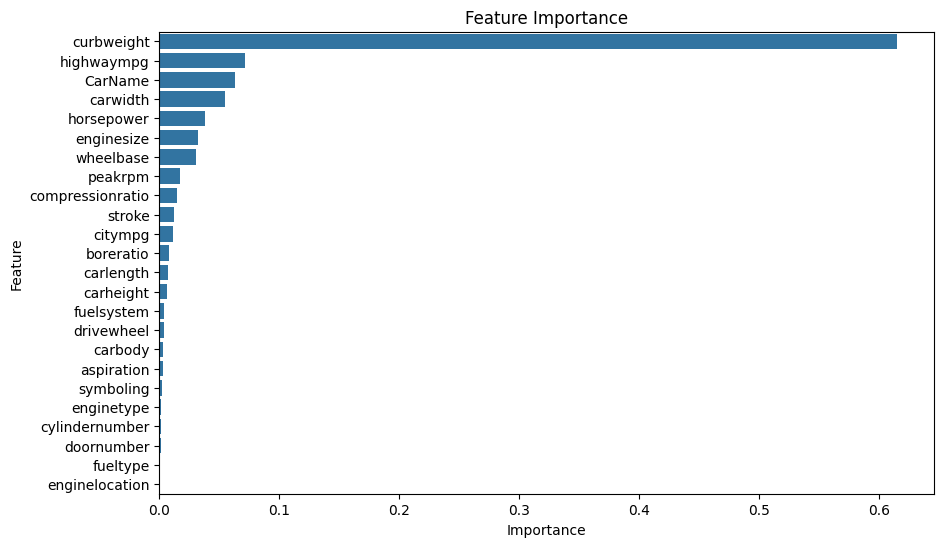

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

## **Actual vs Predicted Visualization**

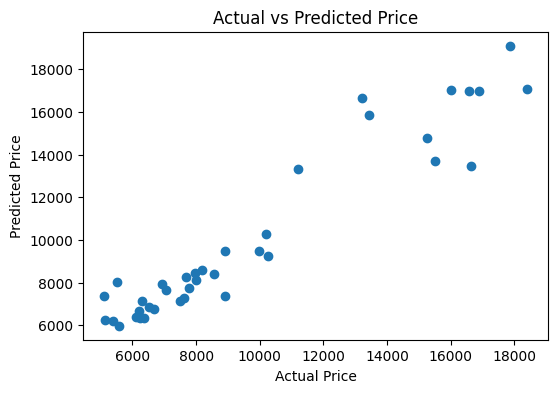

In [64]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Price')

plt.show()

## **Predict Price for New Car**

In [65]:
new_car = [[
    3,
    10,
    1,
    0,
    1,
    2,
    2,
    0,
    95.0,
    170.0,
    65.0,
    52.0,
    2500,
    1,
    2,
    130,
    3,
    3.5,
    3.2,
    9.0,
    120,
    5000,
    22,
    28
]]

In [66]:
new_car_scaled = scaler.transform(new_car)

In [67]:
predicted_price = rf_model.predict(new_car_scaled)

print('Predicted Car Price:',
      predicted_price[0])

Predicted Car Price: 15315.03


## **Conclusion**

In this lab, we developed a Machine Learning-based car price prediction system using automobile data. We performed preprocessing, encoding, feature scaling, outlier handling, and exploratory data analysis to understand feature relationships. Multiple regression models including Linear Regression, Decision Tree, and Random Forest were trained and evaluated using MAE, RMSE, and R² Score. Among all models, Random Forest achieved the best performance and was used to successfully predict car prices for new input data.